In [ ]:
# ELEC 6604 Assignment 1

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score
import copy

# ANN Training
import pandas as pd
import random
import time
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, BatchNormalization
from tensorflow.keras.layers import Dropout
from tensorflow.keras.optimizers import Adam, SGD

In [3]:
# Part 1: Perceptron 12 data points linearly Separable
#-----------------------------------------------------
# Perceptron parameters
W12=-3
W13= 2
theta = -1
learnrate = 0.3

tmpp = np.array([
    [-0.6,  0.8,  1.0],
    [-0.2,  1.2,  1.0],
    [ 0.1,  1.5,  1.0],
    [-0.7,  0.2,  1.0],
    [ 0.3,  1.1,  1.0],
    [-0.4,  1.6,  1.0],
    [ 1.2,  0.3,  0.0],
    [ 1.5,  0.6,  0.0],
    [ 0.8, -0.4,  0.0],
    [ 1.6, -0.2,  0.0],
    [ 0.6, -0.6,  0.0],
    [ 1.1, -0.5,  0.0]
])

print(tmpp.shape)

(12, 3)


In [4]:
X2=tmpp[:,0]
X3=tmpp[:,1]
desiredout=tmpp[:,2]
print('X2 = ', X2)
print('X3 = ', X3)
print('desiredout = ',desiredout)

X2 =  [-0.6 -0.2  0.1 -0.7  0.3 -0.4  1.2  1.5  0.8  1.6  0.6  1.1]
X3 =  [ 0.8  1.2  1.5  0.2  1.1  1.6  0.3  0.6 -0.4 -0.2 -0.6 -0.5]
desiredout =  [1. 1. 1. 1. 1. 1. 0. 0. 0. 0. 0. 0.]


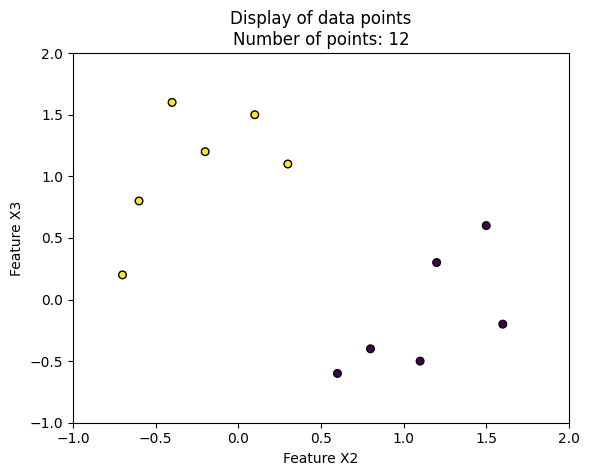

In [5]:
# plot
Num_datapoints = len(X2)
plt.scatter(X2, X3, c=desiredout, cmap='viridis', edgecolors='k', s=30)
plt.title(f'Display of data points\n'
              f'Number of points: {Num_datapoints}')
plt.xlabel('Feature X2')
plt.ylabel('Feature X3')
plt.xlim(-1, 2)  # xmin=-1, xmax=2
plt.ylim(-1, 2)
plt.show()

In [6]:
# training of perceptrons
out = -1
for iteration in range(10):  # i=0,1,2,3,...,9
    totalerror=0
    for j in range(Num_datapoints):  # j=0,1,2,3,....
        tmpout=W12*X2[j]+W13*X3[j]+theta
        if (tmpout > 0):
            out = 1
        else:
            out = 0
        diff = desiredout[j] - out
        W12 = W12 + learnrate*diff*X2[j]; # error correction learning rule
        W13 = W13 + learnrate*diff*X3[j];
        theta = theta + learnrate*diff;
        totalerror = totalerror + np.abs(diff);
        #debug print(iteration, j, totalerror, W12, W13, theta)



In [7]:
# Create meshgrid for decision boundary visualization
xx, yy = np.meshgrid(np.linspace(-1, 2, 100),
                     np.linspace(-1, 2, 100))
print('xx.shape =  ', xx.shape)


xx.shape =   (100, 100)


In [8]:
# Get output for the grid points to plot decision boundaries
percept = copy.deepcopy(xx)

for ixx in range(100):
    for iyy in range(100):
        tmpout=W12*xx[ixx,iyy]+W13*yy[ixx,iyy]+theta
        if (tmpout > 0):
            percept[ixx,iyy] = 1
        else:
            percept[ixx,iyy] = 0

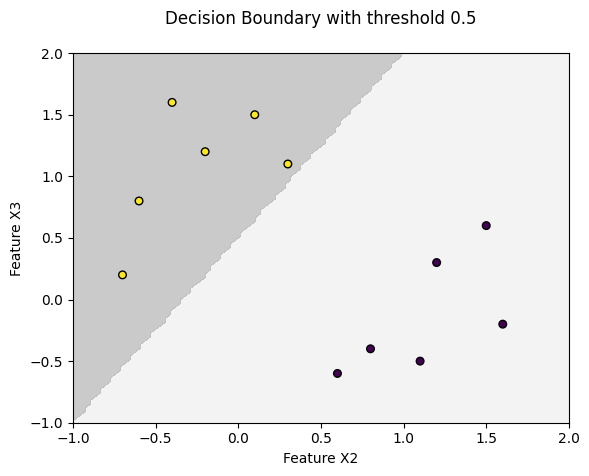

In [9]:
# Visualize the decision boundary
threshold_1 = 0.5

plt.contourf(xx, yy, percept, levels=[0, threshold_1, 1], alpha=0.3, cmap=plt.cm.Greys)
plt.scatter(X2, X3, c=desiredout, cmap='viridis', edgecolors='k', s=30)

plt.title(f'Decision Boundary with threshold {threshold_1}\n')
plt.xlabel('Feature X2')
plt.ylabel('Feature X3')

plt.show()

### part 1

In binary classification, a threshold determines the boundary where an output above it is assigned to one class and below it to another. In this perceptron demo (Slide 6), the grid outputs in percept are hard-thresholded into discrete values (only 0 and 1) rather than continuous probabilities. The contour line plotted by plt.contourf represents the step transition between 0 and 1. Therefore, as long as threshold_1 is set to any value between 0 and 1, the geometrical boundary separating 0 and 1 remains identical, resulting in no change to the plotted figure.

In [5]:
#
# Part 2: ANN 12 data points linearly Separable
#----------------------------------------------
# Keras is demonstrated. It is a high-level API for building and training ANN
# ANN model. The demo is for an ANN with two inputs, one output.
# One hidden layer

Number_hidden_units = 15

def baseline_model1():
    model = Sequential()
    model.add(Dense(Number_hidden_units, activation='relu', input_dim = 2))

    model.add(Dense(1, activation='sigmoid')) # Output layer for binary classification

    model.compile(optimizer=SGD(learning_rate = 0.3),loss='binary_crossentropy',
                  metrics=['accuracy'])

    return model

In [6]:
# training instances are defined
tmpp= np.array([
    [1.0000  ,  1.0000   ,  1.0000],
    [1.0000  ,  0.5000  ,   1.0000],
    [1.5000  ,  0.2000  ,   1.0000],
    [0.5000  ,  0.7500  ,   1.0000],
    [1.2000  ,  1.5000  ,   1.0000],
    [1.6000  ,  1.2000  ,   1.0000],
    [0.5000  ,  0.3000  ,   0.0000],
    [0.5000  ,  -0.7000 ,   0.0000],
    [0.0000  ,  0.2    ,    0.0000],
    [-0.7    ,  0.9000   ,  0.0000],
    [-0.6    ,  -0.5    ,   0.0000],
    [-0.5    ,  0.5     ,   0.0000]
   ])
train_x=tmpp[:,0:2]
train_y=tmpp[:,2]

train_y = train_y.reshape((len(train_y),1))

print(train_x.shape)
print(train_y.shape)

ANN_model = baseline_model1()
ANN_model.summary()

(12, 2)
(12, 1)


/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 15)             │            45 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            16 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 61 (244.00 B)

 Trainable params: 61 (244.00 B)

 Non-trainable params: 0 (0.00 B)

In [7]:
start_time = time.time()

history = ANN_model.fit(train_x, train_y, epochs=100, verbose = 0)
# Use verbose = 1 for details of training

end_time = time.time()
exe_time = end_time - start_time
print("Execution time: ", exe_time)

scores = ANN_model.evaluate(train_x,train_y,verbose = 0)
print("Training Accuracy = ", scores)

Execution time:  6.283930540084839
Training Accuracy =  [0.07986225932836533, 1.0]


In [8]:
xx, yy = np.meshgrid(np.linspace(-1, 2, 300),
                     np.linspace(-1, 2, 300))
grid = np.c_[xx.ravel(), yy.ravel()]
print('grid.shape is ', grid.shape)

print('xx.shape is ', xx.shape)

grid.shape is  (90000, 2)
xx.shape is  (300, 300)


2813/2813 ━━━━━━━━━━━━━━━━━━━━ 4s 1ms/step


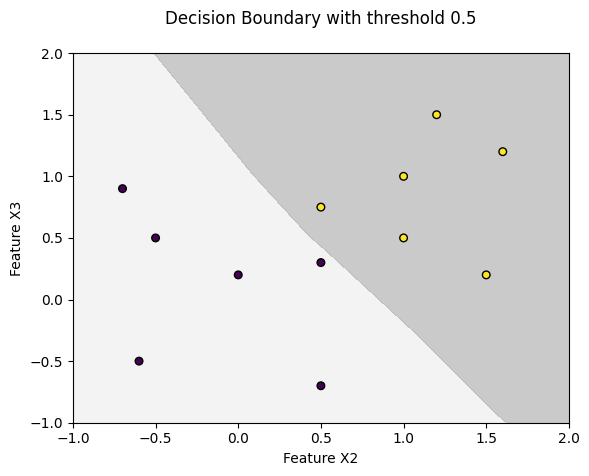

In [9]:
ANN_probs = ANN_model.predict(grid).reshape(xx.shape)

# Visualize the decision boundary
threshold_1 = 0.5

X2=tmpp[:,0]
X3=tmpp[:,1]
desiredout=tmpp[:,2]

plt.contourf(xx, yy, ANN_probs, levels=[0, threshold_1, 1], alpha=0.3,
             cmap=plt.cm.Greys)
plt.scatter(X2, X3, c=desiredout, cmap='viridis', edgecolors='k', s=30)

plt.title(f'Decision Boundary with threshold {threshold_1}\n')
plt.xlabel('Feature X2')
plt.ylabel('Feature X3')

plt.show()

### part 2

In part 2, the decision boundary between the two classes is a curved, non-linear boundary rather than a straight line as seen in the perceptron demo. This occurs because the neural network introduces non-linear activation functions (ReLU in the hidden layer and Sigmoid in the output layer), allowing it to fit a non-linear separating surface even for linearly separable data.


The neural network consists of an input layer (2 features), one hidden layer (15 units), and an output layer (1 unit):   
Hidden Layer: (2 inputs×15 weights)+15 biases=45 parameters.   
Output Layer: (15 inputs×1 weight)+1 bias=16 parameters.   
Total: 45+16=61.

In [18]:
# Part 3: ANN with data points not linearly separable
#----------------------------------------------------
# One hidden layer
# ANN demo: 20 training instances are defined
# These points are not linearly separable
#
tmpp= np.array([
    [1.0000  ,  1.0000   ,  1.0000],
    [1.1000  ,  0.6000  ,   1.0000],
    [1.5000  ,  0.2000  ,   1.0000],
    [-0.5000  , 0.7500  ,   1.0000],
    [-0.5000  , 1.5000  ,   1.0000],
    [-0.1000  , 0.9000  ,   1.0000],
    [ 0.6000  , 1.2    ,    1.0000],
    [1.5000   , 1.5     ,   1.0000],
    [1.8000  ,  1.0000   ,  1.0000],
    [1.8000  ,  0.2000  ,   1.0000],
    [-0.8000  , -0.1000  ,  0.0000],
    [-0.4000  , 0.2000  ,   0.0000],
    [-0.6000  , 0.1500  ,   0.0000],
    [-0.2000  , -0.4000 ,   0.0000],
    [1.2000  ,  0.1    ,    0.0000],
    [1.5    ,  -0.6     ,   0.0000],
    [0.5000  ,  0.7500  ,   0.0000],
    [0.5000  ,  0.3000 ,    0.0000],
    [0.5000  ,  -0.7000 ,   0.0000],
    [0.0000    , 0.2000 ,   0.0000],
   ])
print(tmpp.shape)

(20, 3)


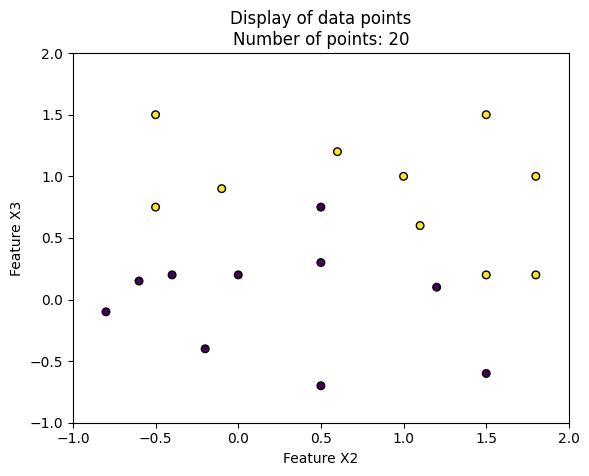

In [19]:
X2=tmpp[:,0]
X3=tmpp[:,1]
desiredout=tmpp[:,2]

Num_datapoints = len(X2)
plt.scatter(X2, X3, c=desiredout, cmap='viridis', edgecolors='k', s=30)
plt.title(f'Display of data points\n'
              f'Number of points: {Num_datapoints}')
plt.xlabel('Feature X2')
plt.ylabel('Feature X3')
plt.xlim(-1, 2)  # xmin=-1, xmax=2
plt.ylim(-1, 2)
plt.show()

In [20]:
# ANN model of the two inputs
# One hidden layer

Number_hidden_units = 20

def baseline_model1():
    model = Sequential()
    model.add(Dense(Number_hidden_units, activation='relu', input_dim = 2))
    model.add(Dense(1, activation='sigmoid')) # Output layer for binary classification

    model.compile(optimizer=SGD(learning_rate = 0.3),loss='binary_crossentropy',
                  metrics=['accuracy'])

    return model

In [21]:
train_x=tmpp[:,0:2]
train_y=tmpp[:,2]
train_y = train_y.reshape((20,1))
print(train_x.shape)
print(train_y.shape)

ANN_model = baseline_model1()
ANN_model.summary()

(20, 2)
(20, 1)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                 │ (None, 20)             │            60 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            21 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 81 (324.00 B)

 Trainable params: 81 (324.00 B)

 Non-trainable params: 0 (0.00 B)

In [22]:

start_time = time.time()

history = ANN_model.fit(train_x, train_y, epochs=400, verbose = 0)
# Use verbose = 1 for details of training

end_time = time.time()
exe_time = end_time - start_time
print("Execution time: ", exe_time)

scores = ANN_model.evaluate(train_x,train_y,verbose = 2)
print("Training Accuracy = ", scores)


Execution time:  20.63823103904724
1/1 - 0s - 164ms/step - accuracy: 1.0000 - loss: 0.0571
Training Accuracy =  [0.057111598551273346, 1.0]


In [23]:
# Make predictions and evaluate the training accuracy
y_pred = ANN_model.predict(train_x)
print(y_pred)
print(train_y)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step
[[9.8476905e-01]
 [8.7333328e-01]
 [8.3570737e-01]
 [9.2147201e-01]
 [9.9998486e-01]
 [9.4292480e-01]
 [9.8473537e-01]
 [9.9998277e-01]
 [9.9992639e-01]
 [9.7568756e-01]
 [6.5035145e-03]
 [1.1109546e-02]
 [1.9112071e-02]
 [4.6672780e-05]
 [2.2241195e-01]
 [1.1728505e-02]
 [2.7158064e-01]
 [1.1593088e-02]
 [4.3963057e-05]
 [2.3340008e-03]]
[[1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]]


In [24]:
xx, yy = np.meshgrid(np.linspace(-1, 2, 300),
                     np.linspace(-1, 2, 300))
grid = np.c_[xx.ravel(), yy.ravel()]
print(grid.shape)


(90000, 2)


In [25]:
ANN_probs = ANN_model.predict(grid).reshape(xx.shape)

2813/2813 ━━━━━━━━━━━━━━━━━━━━ 4s 1ms/step


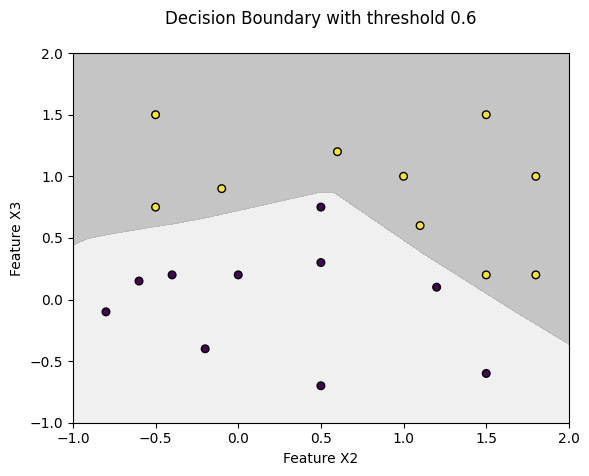

In [27]:
# Visualize the decision boundary
threshold_1 = 0.6

plt.contourf(xx, yy, ANN_probs, levels=[0, threshold_1, 1], alpha=0.3,
             cmap=plt.cm.Greys)
plt.scatter(X2, X3, c=desiredout, cmap='viridis', edgecolors='k', s=30)

plt.title(f'Decision Boundary with threshold {threshold_1}\n')
plt.xlabel('Feature X2')
plt.ylabel('Feature X3')

plt.show()

### part 3

Hidden Layer: (2 inputs×20 weights)+20 biases=60 parameters

Output Layer: (20 inputs×1 weight)+1 bias=21 parameters

Total: 60+21=81

In [28]:
# Part 4: ANN with data points not linearly separable
#----------------------------------------------------
# ANN model of the two inputs, one output
# Two hidden layers

Number_hidden1_units = 15
Number_hidden2_units = 10

def baseline_model2():
    model = Sequential()
    model.add(Dense(Number_hidden1_units, activation='relu', input_dim = 2))
    model.add(Dense(Number_hidden2_units, activation='relu'))
    model.add(Dense(1, activation='sigmoid')) # Output layer for binary classification

    model.compile(optimizer=SGD(learning_rate = 0.15),loss='binary_crossentropy',
                  metrics=['accuracy'])

    return model

ANN_model = baseline_model2()
ANN_model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_6 (Dense)                 │ (None, 15)             │            45 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 10)             │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 1)              │            11 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 216 (864.00 B)

 Trainable params: 216 (864.00 B)

 Non-trainable params: 0 (0.00 B)

In [29]:
# Start training

history = ANN_model.fit(train_x, train_y, epochs=300, verbose = 2)

ANN_probs = ANN_model.predict(grid).reshape(xx.shape)


Epoch 1/300
1/1 - 1s - 506ms/step - accuracy: 0.5000 - loss: 0.6845
Epoch 2/300
1/1 - 0s - 49ms/step - accuracy: 0.5000 - loss: 0.6760
Epoch 3/300
1/1 - 0s - 49ms/step - accuracy: 0.6000 - loss: 0.6673
Epoch 4/300
1/1 - 0s - 45ms/step - accuracy: 0.7000 - loss: 0.6580
Epoch 5/300
1/1 - 0s - 60ms/step - accuracy: 0.7000 - loss: 0.6488
Epoch 6/300
1/1 - 0s - 45ms/step - accuracy: 0.8000 - loss: 0.6395
Epoch 7/300
1/1 - 0s - 44ms/step - accuracy: 0.8500 - loss: 0.6307
Epoch 8/300
1/1 - 0s - 48ms/step - accuracy: 0.8000 - loss: 0.6221
Epoch 9/300
1/1 - 0s - 44ms/step - accuracy: 0.8000 - loss: 0.6138
Epoch 10/300
1/1 - 0s - 44ms/step - accuracy: 0.8500 - loss: 0.6052
Epoch 11/300
1/1 - 0s - 47ms/step - accuracy: 0.9000 - loss: 0.5961
Epoch 12/300
1/1 - 0s - 46ms/step - accuracy: 0.9000 - loss: 0.5871
Epoch 13/300
1/1 - 0s - 48ms/step - accuracy: 0.9000 - loss: 0.5781
Epoch 14/300
1/1 - 0s - 45ms/step - accuracy: 0.9000 - loss: 0.5688
Epoch 15/300
1/1 - 0s - 51ms/step - accuracy: 0.9000 - l

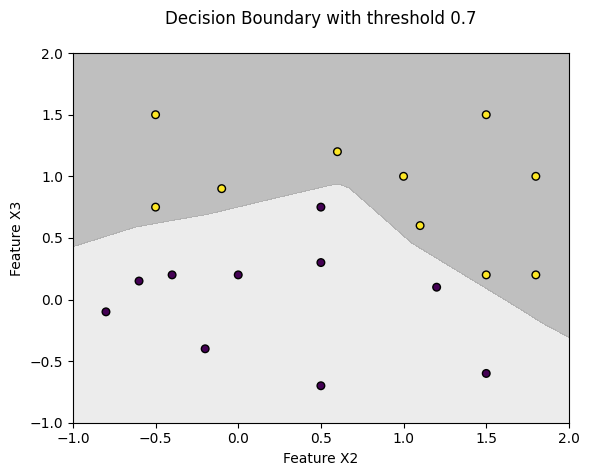

In [32]:
# Visualize the decision boundary
threshold_1 = 0.7

plt.contourf(xx, yy, ANN_probs, levels=[0, threshold_1, 1], alpha=0.3,
             cmap=plt.cm.Greys)
plt.scatter(X2, X3, c=desiredout, cmap='viridis', edgecolors='k', s=30)

plt.title(f'Decision Boundary with threshold {threshold_1}\n')
plt.xlabel('Feature X2')
plt.ylabel('Feature X3')

plt.show()

### part 4

Hidden Layer 1: (2×15)+15=45 parameters

Hidden Layer 2: (15×10)+10=160 parameters

Output Layer: (10×1)+1=11 parameters

Total: 45+160+11=216

Unlike Part 1 where outputs are hard-limited into discrete values (0 or 1), the multi-layer neural network outputs continuous predicted probabilities via the Sigmoid activation function, stored in ANN_probs. The resulting probability landscape is non-linear, and the decision boundary is determined by threshold_1.   

Consequently, modifying threshold_1 redefines the decision contour:Increasing the threshold (e.g., to 0.7) raises the criterion for Class 1, shifting the boundary towards Class 1 and shrinking the dark grey region.   Decreasing the threshold (e.g., to 0.3) lowers the criterion, thereby expanding the dark grey region.

In [ ]:
# Part 5: ANN with data points not linearly separable
#----------------------------------------------------
# The MLPClassifier is a framework in the sklearn.neural_network module
# of the Scikit-learn library. It implements MLP for supervised learning tasks,
# specifically for classification problems.
#
# ANN model of the two inputs, one output
# Three hidden layers is used.

In [83]:
# Another ANN
# Define the hyperparameters for the neural network
hidden_layer_depth = 3  # Number of hidden layers
hidden_layer_width = 25  # Number of neurons per hidden layer

# Create a tuple representing the hidden layer sizes
hidden_layer_sizes = (hidden_layer_width,) * hidden_layer_depth

# Train a neural network on the training dataset
mlp = MLPClassifier(hidden_layer_sizes=hidden_layer_sizes,
                    activation='relu',  # activation function for hidden layers
                    solver='sgd',  # optimization algorithm
                    momentum=0.6,
                    max_iter=2000)
mlp.fit(train_x, train_y.ravel())

MLPClassifier(hidden_layer_sizes=(25, 25, 25), max_iter=2000, momentum=0.6,
              solver='sgd')

In [84]:
print(train_x.shape)
print(train_y.shape)
print(xx.shape)
ANN_probs = mlp.predict(grid).reshape(xx.shape)

(20, 2)
(20, 1)
(300, 300)


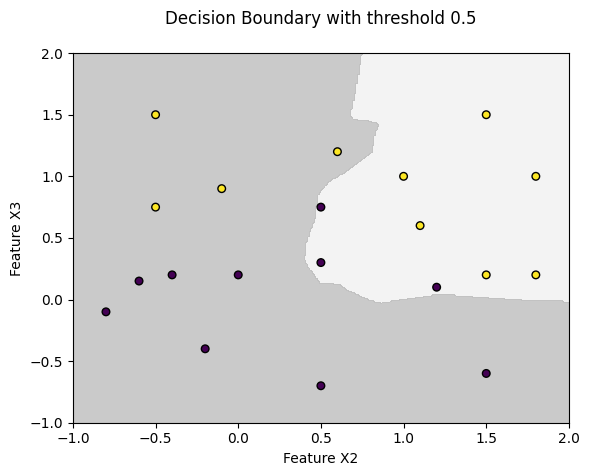

In [85]:
# Visualize the decision boundary
threshold_1 = 0.5

plt.contourf(xx, yy, ANN_probs, levels=[0, threshold_1, 1], alpha=0.3,
             cmap=plt.cm.Greys)
plt.scatter(X2, X3, c=desiredout, cmap='viridis', edgecolors='k', s=30)

plt.title(f'Decision Boundary with threshold {threshold_1}\n')
plt.xlabel('Feature X2')
plt.ylabel('Feature X3')

plt.show()

In [63]:
# Make predictions and evaluate the training accuracy
y_pred = mlp.predict(train_x)
accuracy = accuracy_score(train_y, y_pred)
print(f'Test Accuracy: {accuracy * 100:.2f}%')

Test Accuracy: 100.00%


### part5

When using the adam solver, altering the momentum parameter produces no effect on the resulting decision boundary or accuracy. However, when switching to the sgd solver, modifying momentum leads to significant performance differences: with momentum = 0.9, the network successfully learns the correct decision boundary; whereas with a small value such as momentum = 0.1, the classification error rate increases dramatically.

Under solver='sgd': The momentum parameter controls the inertia coefficient applied to historical gradient updates. In complex loss landscapes (e.g., non-linearly separable classification), a low momentum (such as 0.1) deprives the optimizer of the kinetic momentum required to traverse saddle points, flat ravines, and pathological curvature. Consequently, the optimization trajectory oscillates or gets trapped prematurely, leading to underfitting and poor classification accuracy within the maximum iterations.

Under solver='adam': The momentum argument is strictly inactive and completely ignored by scikit-learn. The Adam optimizer internally computes adaptive moment estimations using its own hyperparameters—first moment and second moment. Thus, external variations to momentum have zero influence on Adam's convergence behavior.

In [ ]:
# Part 6: ANN with many data points not linearly separable
#----------------------------------------------------
# The MLPClassifier is used again in this example.

In [ ]:
# Create a simple dataset
Num_datapoints = 300
X, y = make_moons(n_samples=Num_datapoints, noise=0.1, random_state=42)

In [ ]:
print('X.shape: ', X.shape)
print('y.shape: ', y.shape)
print('min 1st column= ',np.min(X[:,0]), 'max 1st column= ', np.max(X[:,0])  )
print('min 2nd column= ',np.min(X[:,1]), 'max 2nd column= ', np.max(X[:,1])  )
print(X[0:3,:])
print(y)

X.shape:  (300, 2)
y.shape:  (300,)
min 1st column=  -1.2272758742530834 max 1st column=  2.2703863872199213
min 2nd column=  -0.6728418566502035 max 2nd column=  1.239950896359412
[[ 0.68298822 -0.34520334]
 [ 2.04099043 -0.13161467]
 [-0.13975154  0.4543905 ]]
[1 1 1 0 1 1 1 0 0 1 1 0 1 0 1 1 1 1 0 1 0 0 1 1 0 0 1 1 1 1 0 1 0 0 1 0 0
 0 0 0 0 0 1 0 0 0 1 1 0 1 1 0 1 0 1 1 0 0 1 0 1 0 0 1 1 0 0 1 0 1 0 0 1 1
 0 1 0 0 0 1 1 1 0 0 0 0 0 0 0 0 1 0 0 1 0 0 1 0 1 0 1 0 0 1 1 1 0 0 1 0 0
 1 0 1 1 0 0 1 1 1 0 1 1 1 0 1 0 0 1 1 0 0 1 0 1 1 1 1 1 0 0 0 1 0 1 1 0 0
 0 0 1 0 1 1 1 1 1 0 1 0 1 1 0 0 0 0 1 1 1 0 0 1 1 0 0 1 0 0 1 0 1 0 1 1 0
 1 1 1 0 0 0 1 1 1 1 0 1 1 0 1 0 0 0 1 1 1 1 0 0 0 0 1 0 0 1 0 0 1 1 0 0 1
 1 1 0 1 0 0 1 1 0 1 1 1 1 0 0 0 1 1 1 1 1 0 1 0 1 1 1 0 0 0 0 0 0 0 0 0 1
 0 0 0 1 0 0 1 1 0 1 1 0 0 1 1 1 1 1 0 0 1 1 0 1 1 1 1 0 0 1 0 0 1 0 1 0 1
 0 0 1 0]


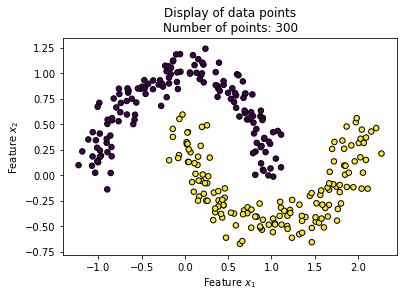

In [ ]:
# Plotting of the dataset # cmap=plt.cm.Greys

plt.scatter(X[:, 0], X[:, 1], c=y, cmap='viridis', edgecolors='k', s=30)
plt.title(f'Display of data points\n'
              f'Number of points: {Num_datapoints}')
plt.xlabel('Feature $x_1$')
plt.ylabel('Feature $x_2$')
plt.show()

In [ ]:

# Split the data into training and testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Standardize the features (important in machine learning)
#scaler = StandardScaler()
#X_train = scaler.fit_transform(X_train)
#X_test = scaler.transform(X_test)

In [ ]:
# Define the hyperparameters for the neural network
hidden_layer_depth = 3  # Number of hidden layers
hidden_layer_width = 15  # Number of neurons per hidden layer

# Create a tuple representing the hidden layer sizes
hidden_layer_sizes = (hidden_layer_width,) * hidden_layer_depth

# Train a neural network on the training dataset
mlp = MLPClassifier(hidden_layer_sizes=hidden_layer_sizes,
                    activation='relu',  # activation function for hidden layers
                    solver='sgd',  # optimization algorithm
                    max_iter=3000)
mlp.fit(X_train, y_train)

MLPClassifier(activation='relu', alpha=0.0001, batch_size='auto', beta_1=0.9,
       beta_2=0.999, early_stopping=False, epsilon=1e-08,
       hidden_layer_sizes=(15, 15, 15), learning_rate='constant',
       learning_rate_init=0.001, max_iter=3000, momentum=0.9,
       n_iter_no_change=10, nesterovs_momentum=True, power_t=0.5,
       random_state=None, shuffle=True, solver='sgd', tol=0.0001,
       validation_fraction=0.1, verbose=False, warm_start=False)

In [ ]:
# Make predictions and evaluate the testset accuracy
y_pred = mlp.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f'Test Accuracy: {accuracy * 100:.2f}%')

Test Accuracy: 100.00%


In [ ]:
# Create meshgrid for decision boundary visualization
x_min, x_max = X_test[:, 0].min() - 0.5, X_test[:, 0].max() + 0.5
y_min, y_max = X_test[:, 1].min() - 0.5, X_test[:, 1].max() + 0.5
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300),
                     np.linspace(y_min, y_max, 300))
grid = np.c_[xx.ravel(), yy.ravel()]
print(grid.shape)

(90000, 2)


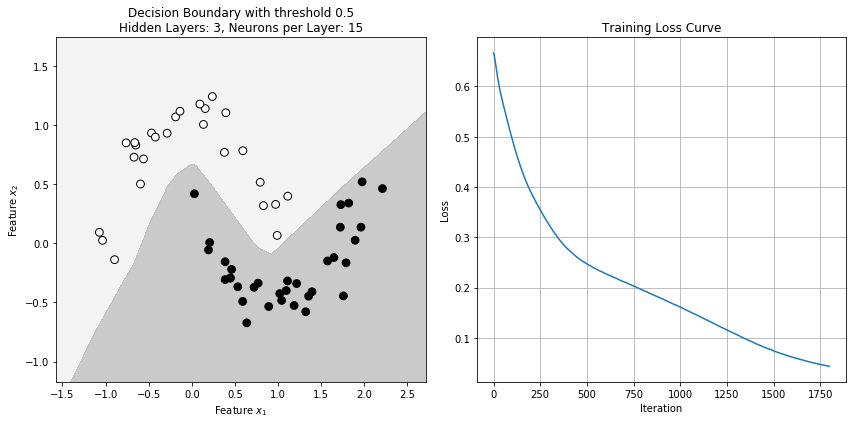

In [ ]:
# Get probabilities for the grid points to plot decision boundaries
# Need to reshape to the same dimension as the xx
probs = mlp.predict_proba(grid)[:, 1].reshape(xx.shape)

fig, axes = plt.subplots(1, 2, figsize=(12, 6))

# Visualize the decision boundary
threshold_1 = 0.5
ax1 = axes[0]
ax1.contourf(xx, yy, probs, levels=[0, threshold_1, 1], alpha=0.3, cmap=plt.cm.Greys)
ax1.scatter(X_test[:, 0], X_test[:, 1], c=y_test, cmap=plt.cm.Greys, edgecolors='k', s=60)
ax1.set_title(f'Decision Boundary with threshold {threshold_1}\n'
              f'Hidden Layers: {hidden_layer_depth}, Neurons per Layer: {hidden_layer_width}')
ax1.set_xlabel('Feature $x_1$')
ax1.set_ylabel('Feature $x_2$')


# Plot the training loss curve
ax2 = axes[1]
ax2.plot(mlp.loss_curve_)
ax2.set_title('Training Loss Curve')
ax2.set_xlabel('Iteration')
ax2.set_ylabel('Loss')
ax2.grid(True)

# Adjust layout for better visualization
plt.tight_layout()
plt.show()

In [ ]:
print(hidden_layer_sizes)

(15, 15, 15)


In [ ]:
# Part 7: ANN with 300 data points using Keras.
#----------------------------------------------
# ANN model of the two inputs, one output
# Two hidden layers

Number_hidden1_units = 15
Number_hidden2_units = 10

def baseline_model2():
    model = Sequential()
    model.add(Dense(Number_hidden1_units, activation='relu', input_dim = 2))
    model.add(Dense(Number_hidden2_units, activation='relu'))
    model.add(Dense(1, activation='sigmoid')) # Output layer for binary classification

    model.compile(optimizer=SGD(learning_rate = 0.15),loss='binary_crossentropy',
                  metrics=['accuracy'])

    return model

ANN_model = baseline_model2()
ANN_model.summary()

Model: "sequential_18"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
dense_42 (Dense)             (None, 15)                45        
_________________________________________________________________
dense_43 (Dense)             (None, 10)                160       
_________________________________________________________________
dense_44 (Dense)             (None, 1)                 11        
Total params: 216
Trainable params: 216
Non-trainable params: 0
_________________________________________________________________


In [ ]:
y_train = y_train.reshape((240,1))
print(X_train.shape)
print(y_train.shape)
print(y_test.shape)

(240, 2)
(240, 1)
(60,)


In [ ]:
# Start training

history = ANN_model.fit(X_train, y_train, epochs=300, verbose = 0)

ANN_probs = ANN_model.predict(grid).reshape(xx.shape)

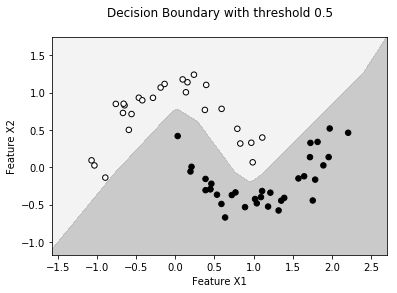

In [ ]:
# Visualize the decision boundary
threshold_1 = 0.5

plt.contourf(xx, yy, ANN_probs, levels=[0, threshold_1, 1], alpha=0.3,
             cmap=plt.cm.Greys)
plt.scatter(X_test[:, 0], X_test[:, 1], c=y_test, cmap=plt.cm.Greys,
            edgecolors='k', s=30)

plt.title(f'Decision Boundary with threshold {threshold_1}\n')
plt.xlabel('Feature X1')
plt.ylabel('Feature X2')

plt.show()

In [ ]:
# Demo of grid
x=np.linspace(0,1,3)
y=np.linspace(0,1,4)
xx, yy = np.meshgrid(x,y)
print('xx.shape = ', xx.shape, 'xx = ', xx)
print('yy.shape = ', yy.shape, 'yy = ' , yy)
kxx=xx.ravel()
print('kxx = ',kxx)
kyy=yy.ravel()
print('kyy = ',kyy)
grid = np.c_[xx.ravel(), yy.ravel()]
print('grid-shape ',  grid.shape)
print('grid = ', grid)

xx.shape =  (4, 3) xx =  [[0.  0.5 1. ]
 [0.  0.5 1. ]
 [0.  0.5 1. ]
 [0.  0.5 1. ]]
yy.shape =  (4, 3) yy =  [[0.         0.         0.        ]
 [0.33333333 0.33333333 0.33333333]
 [0.66666667 0.66666667 0.66666667]
 [1.         1.         1.        ]]
kxx =  [0.  0.5 1.  0.  0.5 1.  0.  0.5 1.  0.  0.5 1. ]
kyy =  [0.         0.         0.         0.33333333 0.33333333 0.33333333
 0.66666667 0.66666667 0.66666667 1.         1.         1.        ]
grid-shape  (12, 2)
grid =  [[0.         0.        ]
 [0.5        0.        ]
 [1.         0.        ]
 [0.         0.33333333]
 [0.5        0.33333333]
 [1.         0.33333333]
 [0.         0.66666667]
 [0.5        0.66666667]
 [1.         0.66666667]
 [0.         1.        ]
 [0.5        1.        ]
 [1.         1.        ]]


zz.shape =  (4, 3)


Text(0, 0.5, 'Feature $x_2$')

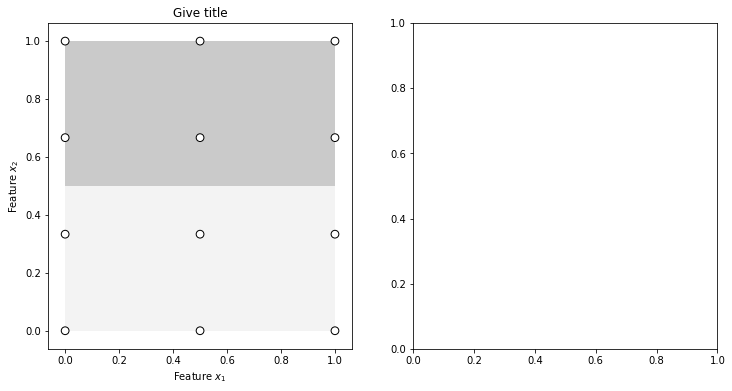

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 6))
zz= np.array([
    [0, 0, 0],
    [0, 0, 0],
    [1, 1, 1],
    [1, 1, 1],
   ])
print('zz.shape = ',zz.shape)
# Visualize the decision boundary
ax1 = axes[0]
ax1.contourf(xx, yy, zz, levels=[0, 0.5, 1], alpha=0.3, cmap=plt.cm.Greys)
ax1.scatter(grid[:, 0], grid[:, 1], c=[1,1,1,1,1,1,1,1,1,1,1,1], cmap=plt.cm.Greys,
            edgecolors='k', s=60)
ax1.set_title('Give title')
ax1.set_xlabel('Feature $x_1$')
ax1.set_ylabel('Feature $x_2$')